# Customer Retention & RFM Analysis — Cohort Retention Analysis

## Business purpose: Track what percentage of customers who first
## purchased in each month returned to buy in subsequent months.
#
## This analysis reveals the true retention rate of the business
## independent of new customer acquisition — showing whether the
## business is genuinely retaining customers or just replacing
## churned customers with new ones.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load cleaned orders data
orders = pd.read_csv(
    "../Data/processed/online_retail_clean.csv",
    parse_dates=['invoicedate']
)

print(f"Transactions loaded: {len(orders):,}")
print(f"Unique customers:    {orders['customer_id'].nunique():,}")
print(f"Date range:          {orders['invoicedate'].min().date()} "
      f"to {orders['invoicedate'].max().date()}")

Transactions loaded: 779,425
Unique customers:    5,878
Date range:          2009-12-01 to 2011-12-09


In [2]:
print("Column names:", orders.columns.tolist())

Column names: ['invoice', 'stockcode', 'description', 'quantity', 'invoicedate', 'price', 'customer_id', 'country', 'revenue']


# Customer Cohort Assignment

In [3]:
# Find each customer's first purchase month

first_purchase = (
    orders.groupby('customer_id')['invoicedate']
    .min()
    .reset_index()
    .rename(columns={'invoicedate': 'first_purchase_date'})
)

first_purchase['cohort_month'] = (
    first_purchase['first_purchase_date'].dt.to_period('M')
)

print(f"Customers assigned to cohorts: {len(first_purchase):,}")
print()
print("Cohort sizes — customers by first purchase month:")
cohort_sizes = first_purchase['cohort_month'].value_counts().sort_index()
print(cohort_sizes)


Customers assigned to cohorts: 5,878

Cohort sizes — customers by first purchase month:
cohort_month
2009-12    955
2010-01    383
2010-02    374
2010-03    443
2010-04    294
2010-05    254
2010-06    270
2010-07    186
2010-08    162
2010-09    243
2010-10    377
2010-11    325
2010-12     76
2011-01     71
2011-02    124
2011-03    179
2011-04    106
2011-05    111
2011-06    108
2011-07    102
2011-08    106
2011-09    189
2011-10    221
2011-11    191
2011-12     28
Freq: M, Name: count, dtype: int64


In [4]:
# Business Observation
# Largest cohort: December 2009 with 955 customers.
# Smallest cohort: December 2011 with 28 customers.

# The exceptionally large cohort in December 2009 aligns with the strong seasonal revenue spike identified in the monthly revenue trend analysis 
# This suggests that holiday-season demand and promotional activities attracted a significant number of first time customers.

# Conversely, the relatively small cohort in December 2011 is likely because the dataset contains only a partial month of data, resulting in fewer recorded new customers.

# Business implication: Customer acquisition appears to be heavily influenced by seasonal shopping patterns, particularly 
# during the year-end holiday period. Marketing campaigns launched during that have the potential to generate the largest influx of new customers.

# Calculate Customer Cohort Age

In [5]:

# Step 2b: Tag every transaction with the customer's cohort month
orders_cohort = orders.merge(
    first_purchase[['customer_id', 'cohort_month']],
    on='customer_id',
    how='left'
)

# Step 2c: Calculate order month for each transaction
orders_cohort['order_month'] = orders_cohort['invoicedate'].dt.to_period('M')

# Step 2d: Calculate cohort index
# Cohort index = how many months after first purchase this transaction happened
# Index 0 = the month they first bought (100% by definition)
# Index 1 = one month later, Index 6 = six months later
orders_cohort['cohort_index'] = (
    orders_cohort['order_month'] - orders_cohort['cohort_month']
).apply(lambda x: x.n)

print("Cohort index range:")
print(f"  Minimum: {orders_cohort['cohort_index'].min()} months")
print(f"  Maximum: {orders_cohort['cohort_index'].max()} months")
print()
print("Sample rows to verify:")
print(orders_cohort[['customer_id', 'invoicedate', 'cohort_month',
                      'order_month', 'cohort_index']].head(8))


Cohort index range:
  Minimum: 0 months
  Maximum: 24 months

Sample rows to verify:
   customer_id         invoicedate cohort_month order_month  cohort_index
0        13085 2009-12-01 07:45:00      2009-12     2009-12             0
1        13085 2009-12-01 07:45:00      2009-12     2009-12             0
2        13085 2009-12-01 07:45:00      2009-12     2009-12             0
3        13085 2009-12-01 07:45:00      2009-12     2009-12             0
4        13085 2009-12-01 07:45:00      2009-12     2009-12             0
5        13085 2009-12-01 07:45:00      2009-12     2009-12             0
6        13085 2009-12-01 07:45:00      2009-12     2009-12             0
7        13085 2009-12-01 07:45:00      2009-12     2009-12             0


In [6]:
# Business Observation
# Every transaction was successfully mapped to its customer's acquisition cohort. 
# The dataset tracks customer behaviour from Month 0 (first purchase) up to Month 24, 
# providing a two-year view of customer retention and repeat purchasing patterns.
# The repeated rows observed are expected because each row represents an individual transaction rather than a unique customer.

# Cohort Retention Matrix

In [7]:

# Count unique customers active in each cohort × month combination
cohort_data = (
    orders_cohort.groupby(['cohort_month', 'cohort_index'])['customer_id']
    .nunique()
    .reset_index()
    .rename(columns={'customer_id': 'customers'})
)

# Pivot to matrix format
# Rows = cohort months, Columns = months since first purchase
cohort_matrix = cohort_data.pivot_table(
    index   = 'cohort_month',
    columns = 'cohort_index',
    values  = 'customers'
)

print("Cohort matrix shape:", cohort_matrix.shape)
print()
print("First 5 cohorts, first 7 months:")
print(cohort_matrix.iloc[:5, :7])


Cohort matrix shape: (25, 25)

First 5 cohorts, first 7 months:
cohort_index      0      1      2      3      4      5      6
cohort_month                                                 
2009-12       955.0  337.0  319.0  406.0  363.0  343.0  360.0
2010-01       383.0   79.0  119.0  117.0  101.0  115.0   99.0
2010-02       374.0   89.0   84.0  109.0   92.0   75.0   72.0
2010-03       443.0   84.0  102.0  107.0  103.0   90.0  109.0
2010-04       294.0   57.0   57.0   48.0   54.0   66.0   81.0


In [8]:
# Business Observation
# The cohort matrix reveals that customer retention is highly concentrated around the initial purchase period. 
# The largest acquisition cohort, December 2009, brought in 955 new customers, but only 337 customers (35.3%) returned in the following month.
# Similar patterns are observed across other cohorts, with January 2010 retaining only 79 of 383 customers (20.6%) after one month and 
# February 2010 retaining 89 of 374 customers (23.8%).

# An important observation is that retention does not decline linearly. For example, the December 2009 cohort records 319 active customers in Month 2,
# which increases to 406 customers in Month 3, indicating that many customers skip one or more months before returning. 
# This suggests that purchasing behaviour is cyclical rather than continuous, making re-engagement campaigns highly valuable.

 #  Key Retention Metrics

In [9]:

retention_matrix = cohort_matrix.divide(
    cohort_matrix.iloc[:, 0],
    axis=0
) * 100

retention_matrix = retention_matrix.round(1)
# Average retention rate at each period across all cohorts
avg_retention = retention_matrix.mean(axis=0)

print("=" * 50)
print("AVERAGE RETENTION RATES ACROSS ALL COHORTS")
print("=" * 50)
print(f"Month 1  (1 month after first purchase):  {avg_retention.get(1,  0):.1f}%")
print(f"Month 2  (2 months after):                {avg_retention.get(2,  0):.1f}%")
print(f"Month 3  (3 months after):                {avg_retention.get(3,  0):.1f}%")
print(f"Month 6  (6 months after):                {avg_retention.get(6,  0):.1f}%")
print(f"Month 12 (12 months after):               {avg_retention.get(12, 0):.1f}%")
print()

# Best and worst performing cohorts at 3 months
retention_3m = retention_matrix[3].dropna()
best_cohort  = retention_3m.idxmax()
worst_cohort = retention_3m.idxmin()

print(f"Best 3-month retention cohort:  {best_cohort} ({retention_3m.max():.1f}%)")
print(f"Worst 3-month retention cohort: {worst_cohort} ({retention_3m.min():.1f}%)")
print()

# What percentage of customers return at all after month 0
ever_returned = (retention_matrix.iloc[:, 1:] > 0).any(axis=1).mean() * 100
print(f"Cohorts where any customer returned: {ever_returned:.1f}%")



AVERAGE RETENTION RATES ACROSS ALL COHORTS
Month 1  (1 month after first purchase):  21.2%
Month 2  (2 months after):                21.9%
Month 3  (3 months after):                21.6%
Month 6  (6 months after):                17.8%
Month 12 (12 months after):               18.2%

Best 3-month retention cohort:  2009-12 (42.5%)
Worst 3-month retention cohort: 2010-12 (9.2%)

Cohorts where any customer returned: 96.0%


In [10]:
# Business Observation
# The business acquires customers consistently, but long-term engagement remains challenging. Across all acquisition periods, 
# approximately 21% of customers return within the first three months, while retention stabilizes around 18% after one year. 
# The strongest cohort, December 2009, achieved an exceptional 42.5% three-month retention rate, whereas the weakest cohort, 
# December 2010, retained only 9.2% of customers. Additionally, 96% of all cohorts generated repeat purchases, demonstrating 
# that the business has a solid foundation of customer loyalty but significant opportunities to improve early-life retention 
# and maximize customer lifetime value.

# Cohort Retention Heatmap

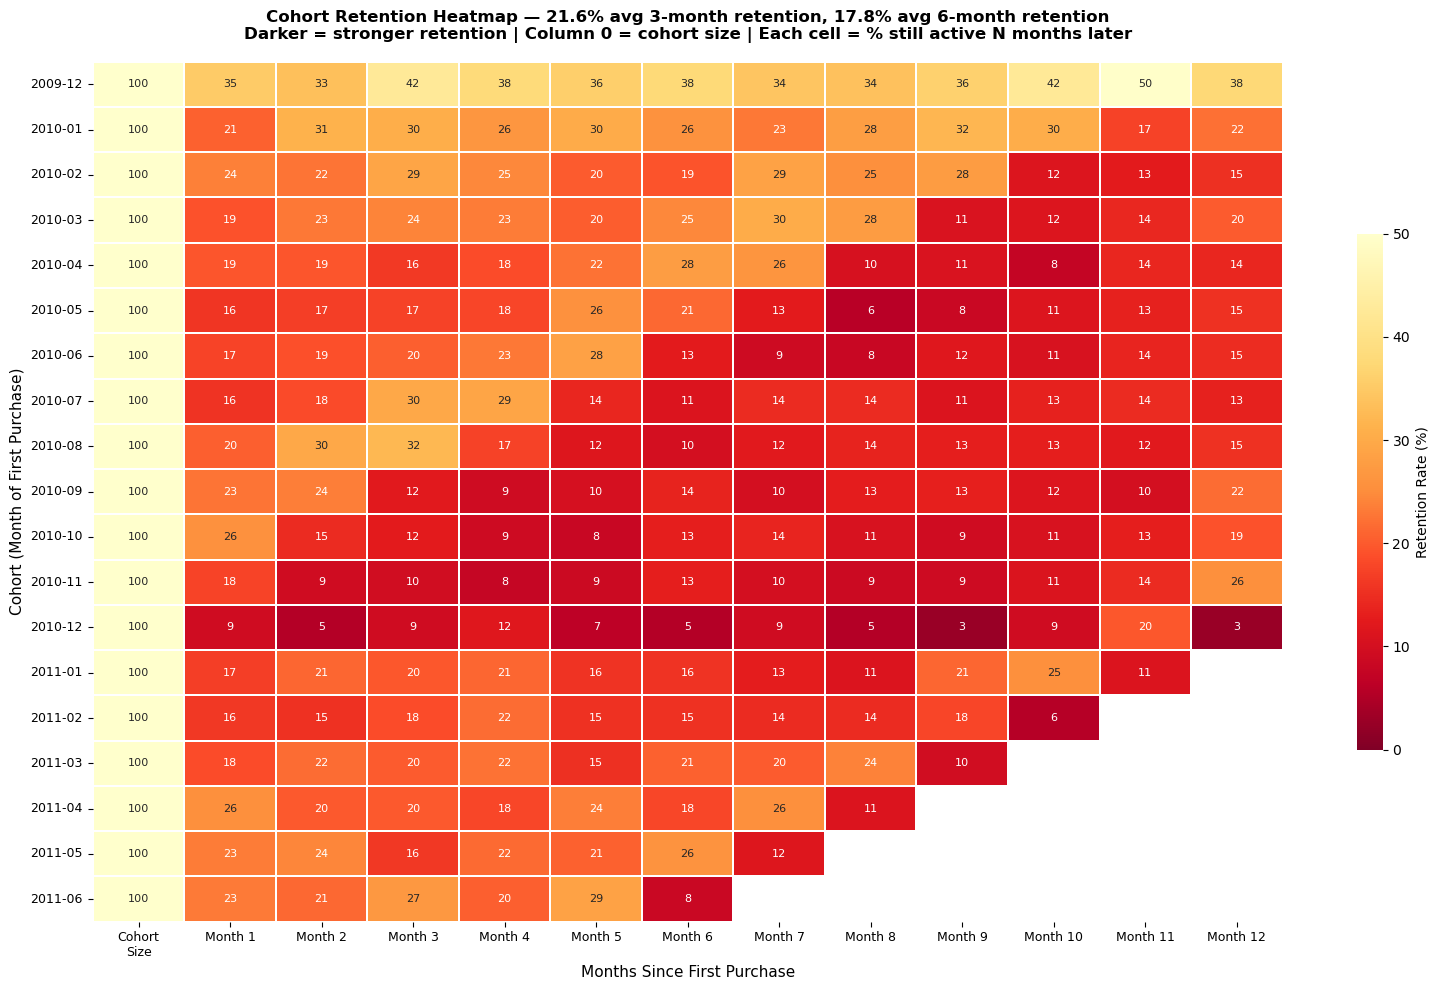

Cohort heatmap saved.
Rows (cohorts shown): 19
Columns (months):     13


In [11]:

# Business question: Which customer cohorts retained best and
#                   how does retention decay over time?

# Limit to cohorts with at least 6 months of data for clean visualisation
cohorts_with_data = retention_matrix[retention_matrix[6].notna()].copy()

# Limit columns to first 13 months (index 0 to 12)
max_months = min(13, retention_matrix.shape[1])
heatmap_data = cohorts_with_data.iloc[:, :max_months]

fig, ax = plt.subplots(figsize=(16, 10))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd_r',       # reversed — green = high retention, red = low
    vmin=0,
    vmax=50,               # cap at 50% so colours show variation clearly
    linewidths=0.3,
    linecolor='white',
    ax=ax,
    cbar_kws={
        'label': 'Retention Rate (%)',
        'shrink': 0.6
    },
    annot_kws={'size': 8}
)

# Format y-axis labels to show month names cleanly
y_labels = [str(p) for p in heatmap_data.index]
ax.set_yticklabels(y_labels, rotation=0, fontsize=9)

# Format x-axis
x_labels = [f'Month {i}' if i > 0 else 'Cohort\nSize'
            for i in heatmap_data.columns]
ax.set_xticklabels(x_labels, rotation=0, fontsize=9)

# Get actual retention values for title
avg_3m = avg_retention.get(3, 0)
avg_6m = avg_retention.get(6, 0)

ax.set_title(
    f'Cohort Retention Heatmap — {avg_3m:.1f}% avg 3-month retention, '
    f'{avg_6m:.1f}% avg 6-month retention\n'
    f'Darker = stronger retention | Column 0 = cohort size | '
    f'Each cell = % still active N months later',
    fontsize=12, fontweight='bold', pad=16
)
ax.set_xlabel('Months Since First Purchase', fontsize=11)
ax.set_ylabel('Cohort (Month of First Purchase)', fontsize=11)

plt.tight_layout()
plt.show()

print(f"Cohort heatmap saved.")
print(f"Rows (cohorts shown): {len(heatmap_data)}")
print(f"Columns (months):     {max_months}")



In [12]:
# Business Observation
# The cohort retention heatmap reveals that customer loyalty declines rapidly after acquisition, with average retention falling to 21.6% 
# by Month 3 and 17.8% by Month 6. 
# The December 2009 cohort stands out as the strongest-performing acquisition group, maintaining retention levels between 35% and 50% 
# throughout the first year. 
# In contrast, the December 2010 cohort experienced significantly weaker engagement, with only around 9% of customers returning after three months.
# Overall, the analysis suggests that while the business consistently acquires new customers, improving early-life retention presents the
# greatest opportunity to increase long-term customer lifetime value.
# On average, only about 1 in 5 customers remains active after 3 months.
# About 18% remain active after 6 months.

# Retention Curve Chart

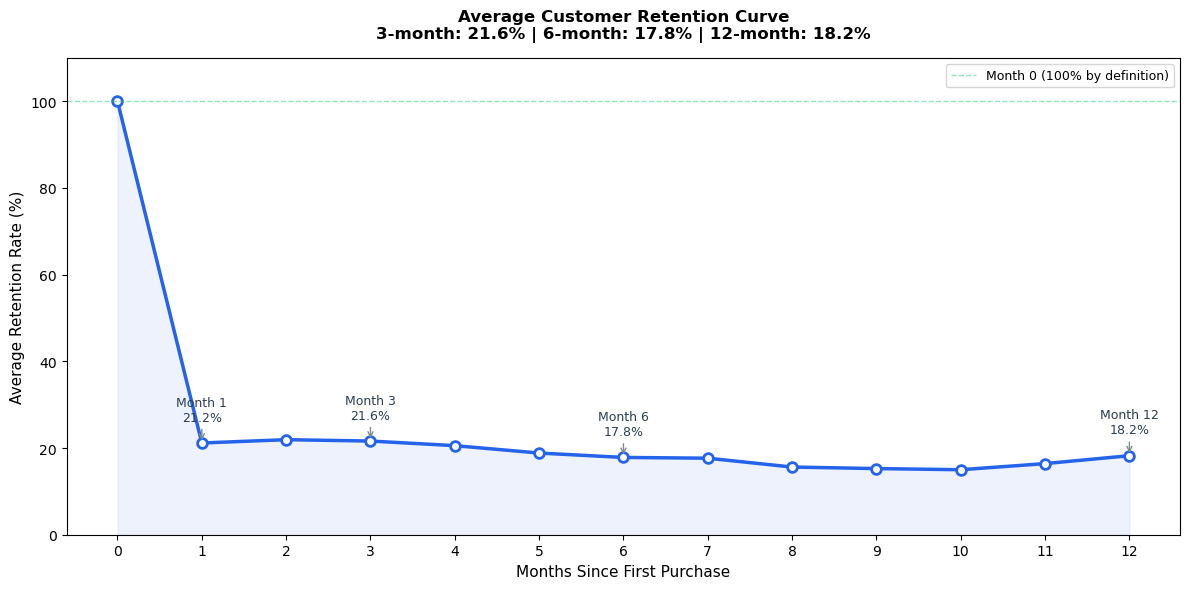

In [13]:

# ── CHART 9: Average retention curve ─────────────────────────────────────
# Business question: On average, what does customer retention look like
#                   from first purchase through 12 months?

# Only use indices 0 through 12
months_to_plot = list(range(0, min(13, len(avg_retention))))
retention_curve = avg_retention[months_to_plot]

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    retention_curve.index,
    retention_curve.values,
    color='#2563eb',
    linewidth=2.5,
    marker='o',
    markersize=7,
    markerfacecolor='white',
    markeredgewidth=2
)

# Fill under curve
ax.fill_between(
    retention_curve.index,
    retention_curve.values,
    alpha=0.08,
    color='#2563eb'
)

# Annotate key points
for month in [1, 3, 6, 12]:
    if month in retention_curve.index:
        val = retention_curve[month]
        ax.annotate(
            f'Month {month}\n{val:.1f}%',
            xy=(month, val),
            xytext=(0, 16),
            textcoords='offset points',
            ha='center',
            fontsize=9,
            color='#2c3e50',
            arrowprops=dict(arrowstyle='->', color='#7f8c8d', lw=1.0)
        )

# Reference line at 100%
ax.axhline(100, color='#2ecc71', linestyle='--',
           linewidth=1, alpha=0.5, label='Month 0 (100% by definition)')

ax.set_title(
    f'Average Customer Retention Curve\n'
    f'3-month: {avg_retention.get(3,0):.1f}% | '
    f'6-month: {avg_retention.get(6,0):.1f}% | '
    f'12-month: {avg_retention.get(12,0):.1f}%',
    fontsize=12, fontweight='bold', pad=14
)
ax.set_xlabel('Months Since First Purchase', fontsize=11)
ax.set_ylabel('Average Retention Rate (%)', fontsize=11)
ax.set_xticks(months_to_plot)
ax.set_ylim(0, 110)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()



In [14]:
# Business Observation
# The customer retention curve reveals that the business experiences significant early-stage customer churn. 
# While all customers are active at acquisition (100%), average retention declines rapidly to 21.2% after one month, 
# suggesting that only about one in five customers make a repeat purchase shortly after joining. Retention then stabilizes, 
# with 21.6% remaining active after three months, 17.8% after six months, and 18.2% after one year.
# This pattern indicates that although the company successfully retains a small group of loyal customers over the long term, 
# improving early repeat purchase behavior represents the largest opportunity for increasing customer lifetime value.

# Since the steepest drop occurs immediately after the first purchase, the business should prioritize post-purchase retention strategies 
# such as welcome email sequences, personalized product recommendations, loyalty rewards, and limited-time repeat purchase discounts. 
# Even a small improvement in Month 1 retention could significantly increase overall customer lifetime value and long-term revenue.

# Best vs Worst Cohort Comparison

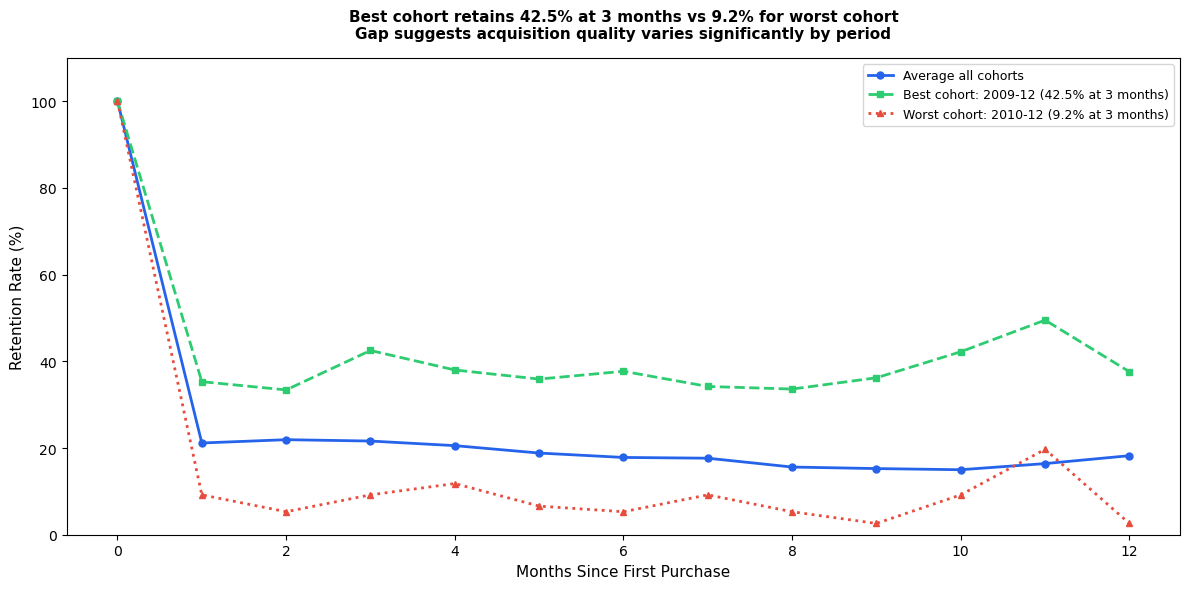

Best cohort:  2009-12 — 42.5% retention at 3 months
Worst cohort: 2010-12 — 9.2% retention at 3 months
Gap: 33.3 percentage points


In [15]:

# ── CHART 10: Best vs worst cohort comparison ─────────────────────────────
# Business question: Which customer cohorts retained best and
#                   what can we learn from them?

retention_3m_clean = retention_matrix[3].dropna()
best_cohort_name   = retention_3m_clean.idxmax()
worst_cohort_name  = retention_3m_clean.idxmin()

best_curve  = retention_matrix.loc[best_cohort_name,  :12].dropna()
worst_curve = retention_matrix.loc[worst_cohort_name, :12].dropna()
avg_curve   = avg_retention[:13]

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(avg_curve.index,   avg_curve.values,
        color='#2563eb', linewidth=2,   linestyle='-',
        marker='o', markersize=5, label='Average all cohorts')

ax.plot(best_curve.index,  best_curve.values,
        color='#2ecc71', linewidth=2,   linestyle='--',
        marker='s', markersize=5,
        label=f'Best cohort: {best_cohort_name} '
              f'({retention_3m_clean.max():.1f}% at 3 months)')

ax.plot(worst_curve.index, worst_curve.values,
        color='#e74c3c', linewidth=2,   linestyle=':',
        marker='^', markersize=5,
        label=f'Worst cohort: {worst_cohort_name} '
              f'({retention_3m_clean.min():.1f}% at 3 months)')

ax.set_title(
    f'Best cohort retains {retention_3m_clean.max():.1f}% at 3 months '
    f'vs {retention_3m_clean.min():.1f}% for worst cohort\n'
    f'Gap suggests acquisition quality varies significantly by period',
    fontsize=11, fontweight='bold', pad=14
)
ax.set_xlabel('Months Since First Purchase', fontsize=11)
ax.set_ylabel('Retention Rate (%)', fontsize=11)
ax.legend(fontsize=9)
ax.set_ylim(0, 110)

plt.tight_layout()
plt.show()

print(f"Best cohort:  {best_cohort_name} — "
      f"{retention_3m_clean.max():.1f}% retention at 3 months")
print(f"Worst cohort: {worst_cohort_name} — "
      f"{retention_3m_clean.min():.1f}% retention at 3 months")
print(f"Gap: {retention_3m_clean.max() - retention_3m_clean.min():.1f} percentage points")



In [16]:
# Business Observation
# Key Findings
# Best cohort: December 2009 → 42.5% retention at Month 3.
# Worst cohort: December 2010 → 9.2% retention at Month 3.
# Performance gap: 33.3 percentage points.
# Best-performing customers retained at roughly 2× the average and nearly 5× the worst cohort.

# The 2009-12 cohort retained 42.5% of customers after 3 months, nearly double the overall average (21.6%).
# In contrast, the 2010-12 cohort retained only 9.2% after 3 months, indicating significantly weaker customer loyalty.
# The difference between the two cohorts is 33.3 percentage points, highlighting substantial variation in customer quality across acquisition periods.
# While the best cohort consistently maintained retention levels above 35% throughout the first year, the weakest cohort remained mostly
# below 10–12%, with only a temporary spike.
# The average retention curve lies between these extremes, suggesting that certain acquisition campaigns or seasonal factors produced 
# much higher-value customers than others.

# The large retention gap suggests that customer acquisition quality matters more than acquisition volume. 
# Customers acquired during December 2009 likely came from stronger seasonal demand or more effective marketing channels, 
# resulting in higher long-term engagement. Replicating the acquisition strategies used during high-performing periods could substantially 
# improve overall customer lifetime value and reduce churn. Conversely, acquisition campaigns resembling the December 2010 cohort should 
# be investigated and optimized, as they attracted customers with significantly lower repeat purchase behavior.

# Save Cohort Data

In [17]:

retention_matrix.to_csv('cohort_retention.csv')
cohort_matrix.to_csv('cohort_counts.csv')

print("Files saved:")
print(" cohort_retention.csv")
print(" cohort_counts.csv")
print()
print("=" * 55)
print("DAY 8 SUMMARY — COHORT RETENTION ANALYSIS")
print("=" * 55)
print(f"Total cohorts analysed:    {len(retention_matrix)}")
print(f"Average 1-month retention: {avg_retention.get(1,  0):.1f}%")
print(f"Average 3-month retention: {avg_retention.get(3,  0):.1f}%")
print(f"Average 6-month retention: {avg_retention.get(6,  0):.1f}%")
print(f"Average 12-month retention:{avg_retention.get(12, 0):.1f}%")
print(f"Best cohort (3-month):     {best_cohort_name} "
      f"({retention_3m_clean.max():.1f}%)")
print(f"Worst cohort (3-month):    {worst_cohort_name} "
      f"({retention_3m_clean.min():.1f}%)")
print()
print("Charts produced:")
print("  chart8_cohort_heatmap.png")
print("  chart9_retention_curve.png")
print("  chart10_best_worst_cohort.png")

Files saved:
 cohort_retention.csv
 cohort_counts.csv

DAY 8 SUMMARY — COHORT RETENTION ANALYSIS
Total cohorts analysed:    25
Average 1-month retention: 21.2%
Average 3-month retention: 21.6%
Average 6-month retention: 17.8%
Average 12-month retention:18.2%
Best cohort (3-month):     2009-12 (42.5%)
Worst cohort (3-month):    2010-12 (9.2%)

Charts produced:
  chart8_cohort_heatmap.png
  chart9_retention_curve.png
  chart10_best_worst_cohort.png


# Business Insights: Cohort Retention Analysis

In [18]:
# The cohort retention heatmap shows a clear pattern of customer churn over time. On average, the business retains 21.6% of customers 
# after 3 months and 17.8% after 6 months. Compared with the typical retail industry benchmark of 25–35% 3-month retention, 
# the company's performance is slightly below average, indicating an opportunity to strengthen early customer engagement.

# Among all cohorts, the December 2009 cohort performed the best, retaining 42.5% of customers after 3 months, while the December 2010 
# cohort retained only 9.2%. Interestingly, the strongest-performing cohort aligns with one of the highest revenue periods identified during
# the monthly trend analysis, suggesting that customers acquired during peak seasonal demand may have higher long-term value and stronger 
# repeat purchase behaviour.

# The average retention curve reveals a sharp decline from 100% at acquisition to 21.2% after the first month, indicating that the business 
# faces a significant first-purchase-to-second-purchase challenge. However, retention becomes relatively stable after the third month, 
# remaining between 17% and 22% throughout the first year. This suggests that customers who continue purchasing beyond the first few months are
# much more likely to become long-term loyal buyers.

# From a business perspective, the greatest opportunity lies in improving early-stage customer retention. 
# A structured onboarding programme could help address this issue, including a welcome email Around day 7, a personalised follow-up 
# recommendation around Day 21, and a loyalty programme invitation around Day 45. Increasing 3-month retention by even 
# 5 percentage points could significantly increase the number of customers progressing into high-value segments such as 
# Loyal Customers and Champions, ultimately improving customer lifetime value and long-term revenue growth.